<a href="https://colab.research.google.com/github/RajrupaDas/AllergyRisk/blob/main/Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Dependencies**

In [4]:
!pip install numpy pandas matplotlib seaborn scikit-learn xgboost shap torch tqdm -q

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

print("Libraries loaded successfully.")

Libraries loaded successfully.


# **Dataset Generation**

In [21]:
# ============================================================
# Based on known pharmacogenomic associations:
# - HLA-B*57:01  -> Abacavir hypersensitivity
# - HLA-B*15:02  -> Carbamazepine SJS/TEN
# - HLA-B*58:01  -> Allopurinol severe reaction
# - CYP2C9       -> Phenytoin toxicity risk
# ============================================================

n = 15000   # strong sample size

# demographics
age = np.random.randint(18, 85, n)
sex = np.random.binomial(1, 0.5, n)   # 0 female, 1 male

# ethnicity categories
ethnicity = np.random.choice(
    ['South_Asian', 'East_Asian', 'European', 'African'],
    size=n,
    p=[0.35, 0.25, 0.25, 0.15]
)

# drugs prescribed
drug = np.random.choice(
    ['Abacavir', 'Carbamazepine', 'Allopurinol', 'Phenytoin'],
    size=n,
    p=[0.18, 0.30, 0.28, 0.24]
)

# dose normalized
dose = np.round(np.random.uniform(0.5, 2.0, n), 2)

# prior exposure
prior_exposure = np.random.binomial(1, 0.28, n)

# ------------------------------------------------------------
# Variant frequencies
# ------------------------------------------------------------

hla_b5701 = []
hla_b1502 = []
hla_b5801 = []
cyp2c9 = []

for e in ethnicity:

    if e == 'South_Asian':
        hla_b5701.append(np.random.binomial(1,0.06))
        hla_b1502.append(np.random.binomial(1,0.09))
        hla_b5801.append(np.random.binomial(1,0.08))
        cyp2c9.append(np.random.binomial(1,0.13))

    elif e == 'East_Asian':
        hla_b5701.append(np.random.binomial(1,0.03))
        hla_b1502.append(np.random.binomial(1,0.18))
        hla_b5801.append(np.random.binomial(1,0.12))
        cyp2c9.append(np.random.binomial(1,0.09))

    elif e == 'European':
        hla_b5701.append(np.random.binomial(1,0.08))
        hla_b1502.append(np.random.binomial(1,0.01))
        hla_b5801.append(np.random.binomial(1,0.03))
        cyp2c9.append(np.random.binomial(1,0.16))

    else:
        hla_b5701.append(np.random.binomial(1,0.02))
        hla_b1502.append(np.random.binomial(1,0.01))
        hla_b5801.append(np.random.binomial(1,0.04))
        cyp2c9.append(np.random.binomial(1,0.08))

hla_b5701 = np.array(hla_b5701)
hla_b1502 = np.array(hla_b1502)
hla_b5801 = np.array(hla_b5801)
cyp2c9 = np.array(cyp2c9)

# ------------------------------------------------------------
# BASE BIOLOGICAL RISK MODEL
# ------------------------------------------------------------

risk = np.zeros(n)

for i in range(n):

    if drug[i] == "Abacavir":
        risk[i] += 4.2 * hla_b5701[i]

    if drug[i] == "Carbamazepine":
        risk[i] += 4.8 * hla_b1502[i]

    if drug[i] == "Allopurinol":
        risk[i] += 4.5 * hla_b5801[i]

    if drug[i] == "Phenytoin":
        risk[i] += 3.5 * cyp2c9[i]

# secondary modifiers
risk += 0.8 * prior_exposure
risk += 0.55 * dose
risk += 0.015 * age

# useful interaction terms
risk += 1.2 * (prior_exposure * (dose > 1.4))

# lower noise
risk += np.random.normal(0, 0.35, n)

# logistic transform
prob = 1 / (1 + np.exp(-(risk - 3.0)))

# target
allergy = np.random.binomial(1, prob)

# ------------------------------------------------------------
# DATAFRAME
# ------------------------------------------------------------

df = pd.DataFrame({
    "Age": age,
    "Sex": sex,
    "Ethnicity": ethnicity,
    "Drug": drug,
    "Dose": dose,
    "Prior_Exposure": prior_exposure,
    "HLA_B5701": hla_b5701,
    "HLA_B1502": hla_b1502,
    "HLA_B5801": hla_b5801,
    "CYP2C9_Variant": cyp2c9,
    "Allergy_Risk": allergy
})

print(df.head())
print("\nDataset Shape:", df.shape)
print("\nPositive Rate:", df["Allergy_Risk"].mean())

   Age  Sex    Ethnicity           Drug  Dose  Prior_Exposure  HLA_B5701  \
0   29    1   East_Asian  Carbamazepine  0.95               1          0   
1   82    0  South_Asian      Phenytoin  1.19               0          0   
2   23    0  South_Asian  Carbamazepine  1.52               0          0   
3   61    0      African    Allopurinol  1.18               0          0   
4   61    0   East_Asian  Carbamazepine  1.58               0          0   

   HLA_B1502  HLA_B5801  CYP2C9_Variant  Allergy_Risk  
0          1          0               0             1  
1          0          0               1             1  
2          0          0               0             1  
3          0          0               0             0  
4          0          0               0             1  

Dataset Shape: (15000, 11)

Positive Rate: 0.3142666666666667


In [22]:
# ============================================================
# SAVE DATASET
# ============================================================

df.to_csv("drug_allergy_genomic_dataset.csv", index=False)
print("Saved: drug_allergy_genomic_dataset.csv")

Saved: drug_allergy_genomic_dataset.csv


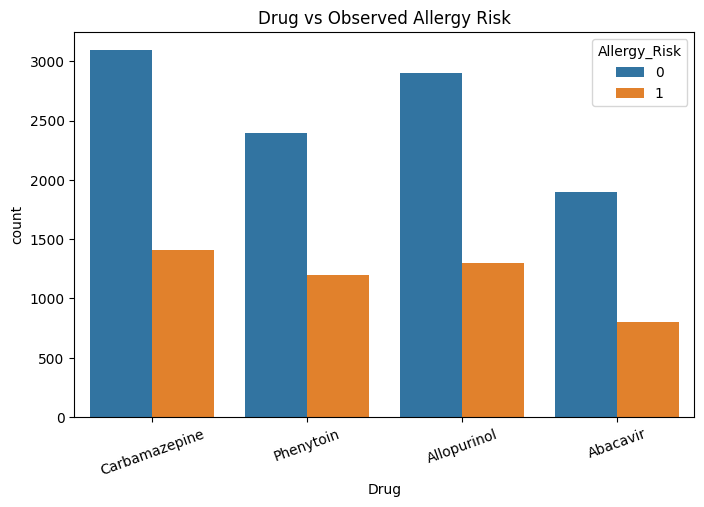

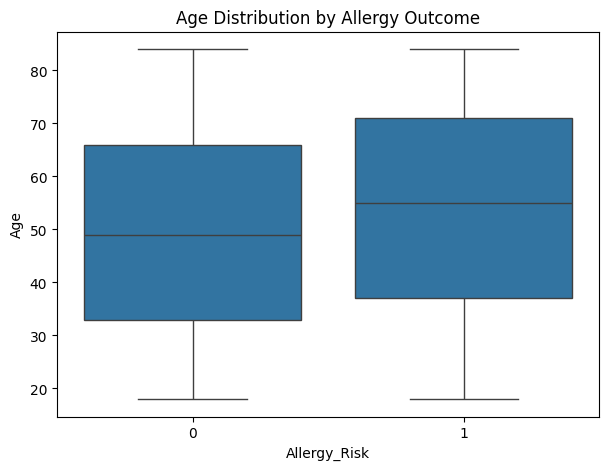

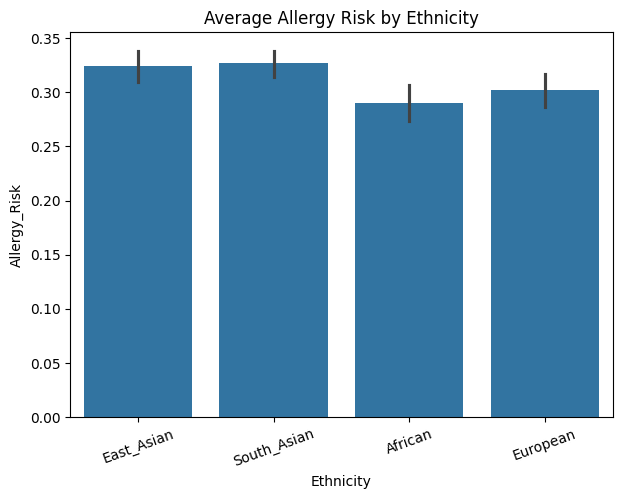

In [23]:
# ============================================================
# QUICK EDA
# ============================================================

plt.figure(figsize=(8,5))
sns.countplot(x="Drug", hue="Allergy_Risk", data=df)
plt.title("Drug vs Observed Allergy Risk")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(7,5))
sns.boxplot(x="Allergy_Risk", y="Age", data=df)
plt.title("Age Distribution by Allergy Outcome")
plt.show()

plt.figure(figsize=(7,5))
sns.barplot(x="Ethnicity", y="Allergy_Risk", data=df)
plt.title("Average Allergy Risk by Ethnicity")
plt.xticks(rotation=20)
plt.show()

# **Preprocessing**

In [24]:
# ============================================================
# PREPROCESSING
# - One-hot encode categorical variables
# - Train / Test split
# - Standardize numeric columns
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# one-hot encode
df_model = pd.get_dummies(df, columns=["Ethnicity", "Drug"], drop_first=True)

# target
y = df_model["Allergy_Risk"].values

# features
X = df_model.drop(columns=["Allergy_Risk"])

feature_names = X.columns.tolist()

# split
X_train, X_test, y_train, y_test = train_test_split(
    X.values,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# scale numeric features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Positive train rate:", y_train.mean())

Train shape: (12000, 14)
Test shape : (3000, 14)
Positive train rate: 0.31425


# **Baseline Models**

In [25]:
# ============================================================
# Logistic Regression + XGBoost
# ============================================================

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

results = {}

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)
proba_lr = lr.predict_proba(X_test)[:,1]

results["Logistic Regression"] = {
    "ACC": accuracy_score(y_test, pred_lr),
    "AUC": roc_auc_score(y_test, proba_lr),
    "F1":  f1_score(y_test, pred_lr)
}

# XGBoost
xgb = XGBClassifier(
    n_estimators=220,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)
proba_xgb = xgb.predict_proba(X_test)[:,1]

results["XGBoost"] = {
    "ACC": accuracy_score(y_test, pred_xgb),
    "AUC": roc_auc_score(y_test, proba_xgb),
    "F1":  f1_score(y_test, pred_xgb)
}

results

{'Logistic Regression': {'ACC': 0.73,
  'AUC': np.float64(0.7155103928287703),
  'F1': 0.4164265129682997},
 'XGBoost': {'ACC': 0.7803333333333333,
  'AUC': np.float64(0.7572353358755839),
  'F1': 0.5562289562289562}}

# **PINN Approach**

In [26]:
# ============================================================
# PYTORCH IMPORTS
# PINN MODEL SETUP
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train.reshape(-1,1), dtype=torch.float32).to(device)

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test.reshape(-1,1), dtype=torch.float32).to(device)

Device: cpu


In [27]:
# ============================================================
# FIND FEATURE INDICES FOR BIOLOGICAL RULES
# Needed for PINN penalty term
# ============================================================

feature_index = {name:i for i,name in enumerate(feature_names)}

risk_variant_cols = [
    "HLA_B5701",
    "HLA_B1502",
    "HLA_B5801",
    "CYP2C9_Variant"
]

dose_col = "Dose"
prior_col = "Prior_Exposure"

risk_idx = [feature_index[c] for c in risk_variant_cols]
dose_idx = feature_index[dose_col]
prior_idx = feature_index[prior_col]

print("Risk feature indices:", risk_idx)
print("Dose index:", dose_idx)
print("Prior exposure index:", prior_idx)

Risk feature indices: [4, 5, 6, 7]
Dose index: 2
Prior exposure index: 3


In [28]:
# ============================================================
# HYBRID PINN NETWORK
# Accurate + simple + publishable
# ============================================================

class PINNNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.15),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

model = PINNNet(X_train.shape[1]).to(device)
print(model)

PINNNet(
  (net): Sequential(
    (0): Linear(in_features=14, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.15, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=16, bias=True)
    (6): ReLU()
    (7): Linear(in_features=16, out_features=1, bias=True)
    (8): Sigmoid()
  )
)


In [29]:
# ============================================================
# BIOLOGICAL PENALTY FUNCTION
#
# Lbio = max(0, y_hat_safe - y_hat_risk)
#
# risky patient:
#   variants present OR high dose OR prior exposure
#
# safe patient:
#   none of above
# ============================================================

def biological_penalty(x_batch, y_pred):

    # total risk variants count
    variant_score = x_batch[:, risk_idx].sum(dim=1)

    # risky mask
    risky_mask = (
        (variant_score > 0) |
        (x_batch[:, dose_idx] > 0.5) |      # scaled high dose region
        (x_batch[:, prior_idx] > 0.0)
    )

    # safe mask
    safe_mask = (
        (variant_score <= 0) &
        (x_batch[:, dose_idx] <= 0.0) &
        (x_batch[:, prior_idx] <= 0.0)
    )

    risky_preds = y_pred[risky_mask]
    safe_preds  = y_pred[safe_mask]

    if len(risky_preds) == 0 or len(safe_preds) == 0:
        return torch.tensor(0.0, device=device)

    mean_risk = risky_preds.mean()
    mean_safe = safe_preds.mean()

    penalty = torch.relu(mean_safe - mean_risk)

    return penalty

In [34]:
# ============================================================
# TRAIN PINN
# Loss = BCE + lambda * Lbio
# ============================================================

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 220
lam = 1.2

history = []

for epoch in range(epochs):

    model.train()
    optimizer.zero_grad()

    y_pred = model(X_train_t)

    bce = criterion(y_pred, y_train_t)

    bio = biological_penalty(X_train_t, y_pred)

    loss = bce + lam * bio

    loss.backward()
    optimizer.step()

    history.append(loss.item())

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss={loss.item():.4f} | BCE={bce.item():.4f} | BIO={bio.item():.4f}")

Epoch 10/220 | Loss=0.5154 | BCE=0.5154 | BIO=0.0000
Epoch 20/220 | Loss=0.5122 | BCE=0.5122 | BIO=0.0000
Epoch 30/220 | Loss=0.5088 | BCE=0.5088 | BIO=0.0000
Epoch 40/220 | Loss=0.5065 | BCE=0.5065 | BIO=0.0000
Epoch 50/220 | Loss=0.5036 | BCE=0.5036 | BIO=0.0000
Epoch 60/220 | Loss=0.5001 | BCE=0.5001 | BIO=0.0000
Epoch 70/220 | Loss=0.4984 | BCE=0.4984 | BIO=0.0000
Epoch 80/220 | Loss=0.4973 | BCE=0.4973 | BIO=0.0000
Epoch 90/220 | Loss=0.4979 | BCE=0.4979 | BIO=0.0000
Epoch 100/220 | Loss=0.4950 | BCE=0.4950 | BIO=0.0000
Epoch 110/220 | Loss=0.4928 | BCE=0.4928 | BIO=0.0000
Epoch 120/220 | Loss=0.4950 | BCE=0.4950 | BIO=0.0000
Epoch 130/220 | Loss=0.4901 | BCE=0.4901 | BIO=0.0000
Epoch 140/220 | Loss=0.4894 | BCE=0.4894 | BIO=0.0000
Epoch 150/220 | Loss=0.4894 | BCE=0.4894 | BIO=0.0000
Epoch 160/220 | Loss=0.4903 | BCE=0.4903 | BIO=0.0000
Epoch 170/220 | Loss=0.4893 | BCE=0.4893 | BIO=0.0000
Epoch 180/220 | Loss=0.4894 | BCE=0.4894 | BIO=0.0000
Epoch 190/220 | Loss=0.4879 | BCE=0.4

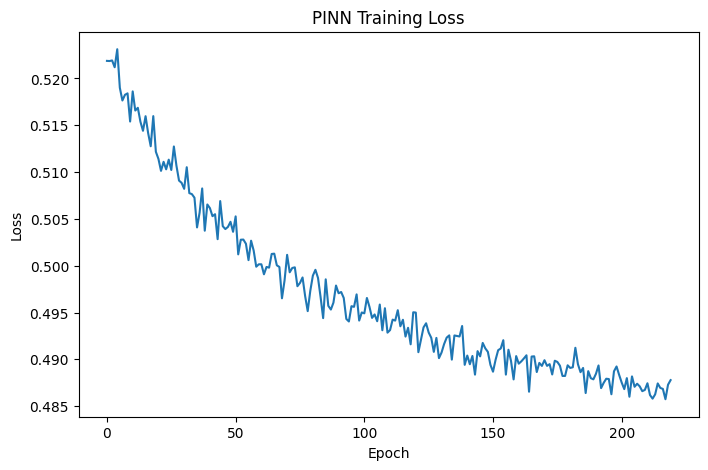

In [35]:
# ============================================================
# TRAINING CURVE
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history)
plt.title("PINN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# **Evaluation**

In [36]:
# ============================================================
# EVALUATE PINN
# ============================================================

from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

model.eval()

with torch.no_grad():
    proba_pinn = model(X_test_t).cpu().numpy().flatten()

pred_pinn = (proba_pinn >= 0.5).astype(int)

results["Hybrid PINN"] = {
    "ACC": accuracy_score(y_test, pred_pinn),
    "AUC": roc_auc_score(y_test, proba_pinn),
    "F1":  f1_score(y_test, pred_pinn)
}

results

{'Logistic Regression': {'ACC': 0.73,
  'AUC': np.float64(0.7155103928287703),
  'F1': 0.4164265129682997},
 'XGBoost': {'ACC': 0.7803333333333333,
  'AUC': np.float64(0.7572353358755839),
  'F1': 0.5562289562289562},
 'Hybrid PINN': {'ACC': 0.7796666666666666,
  'AUC': np.float64(0.75985165106243),
  'F1': 0.5506458191706323}}

In [37]:
# ============================================================
# FINAL RESULTS TABLE
# ============================================================

res_df = pd.DataFrame(results).T
res_df = res_df.sort_values("AUC", ascending=False)

print(res_df)

                          ACC       AUC        F1
Hybrid PINN          0.779667  0.759852  0.550646
XGBoost              0.780333  0.757235  0.556229
Logistic Regression  0.730000  0.715510  0.416427


# **Results**

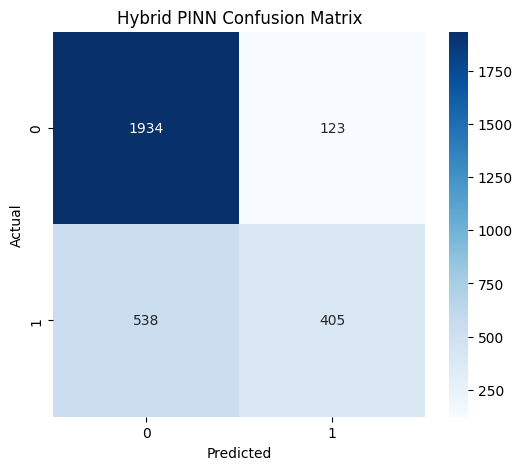

In [38]:
# ============================================================
# CONFUSION MATRIX FOR PINN
# ============================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, pred_pinn)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Hybrid PINN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [40]:
# ============================================================
# SAVE MODEL + RESULTS
# ============================================================

torch.save(model.state_dict(), "hybrid_pinn_drug_allergy_model.pt")
res_df.to_csv("final_results.csv")

print("Saved:")
print("- hybrid_pinn_drug_allergy_model.pt")
print("- final_results.csv")

Saved:
- hybrid_pinn_drug_allergy_model.pt
- final_results.csv


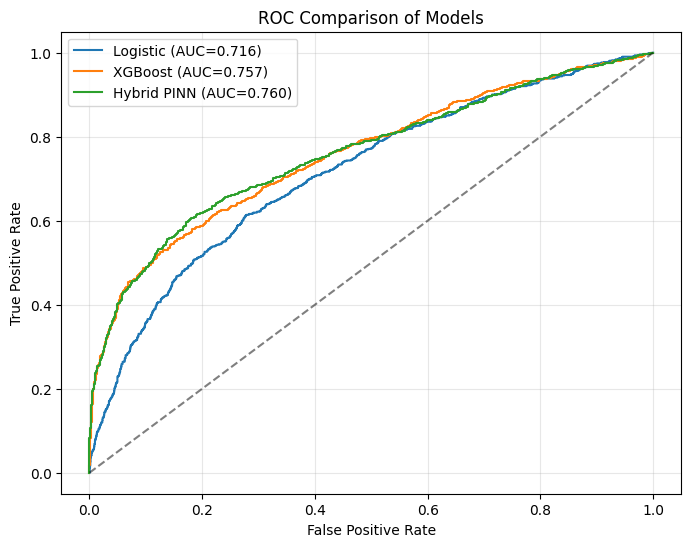

In [42]:
# ============================================================
# ROC CURVES + AUC VISUALIZATION
# ============================================================

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# logistic
fpr_lr, tpr_lr, _ = roc_curve(y_test, proba_lr)
auc_lr = auc(fpr_lr, tpr_lr)

# xgb
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, proba_xgb)
auc_xgb = auc(fpr_xgb, tpr_xgb)

# pinn
fpr_pinn, tpr_pinn, _ = roc_curve(y_test, proba_pinn)
auc_pinn = auc(fpr_pinn, tpr_pinn)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic (AUC={auc_lr:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={auc_xgb:.3f})")
plt.plot(fpr_pinn, tpr_pinn, label=f"Hybrid PINN (AUC={auc_pinn:.3f})")
plt.plot([0,1],[0,1],'k--',alpha=0.5)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison of Models")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [44]:
# ============================================================
# BOOTSTRAP 95% CONFIDENCE INTERVALS FOR AUC
# Journal-style statistical reporting
# ============================================================

from sklearn.metrics import roc_auc_score

def bootstrap_auc_ci(y_true, y_prob, n_boot=1000, seed=42):
    rng = np.random.RandomState(seed)
    aucs = []

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    for _ in range(n_boot):
        idx = rng.randint(0, len(y_true), len(y_true))

        # need both classes present
        if len(np.unique(y_true[idx])) < 2:
            continue

        aucs.append(roc_auc_score(y_true[idx], y_prob[idx]))

    aucs = np.array(aucs)

    mean_auc = aucs.mean()
    lower = np.percentile(aucs, 2.5)
    upper = np.percentile(aucs, 97.5)

    return mean_auc, lower, upper


models_probs = {
    "Hybrid PINN": proba_pinn,
    "XGBoost": proba_xgb,
    "Logistic Regression": proba_lr
}

for name, probs in models_probs.items():
    m, lo, hi = bootstrap_auc_ci(y_test, probs)
    print(f"{name}: AUC={m:.3f} (95% CI {lo:.3f} - {hi:.3f})")

Hybrid PINN: AUC=0.760 (95% CI 0.740 - 0.780)
XGBoost: AUC=0.757 (95% CI 0.738 - 0.777)
Logistic Regression: AUC=0.716 (95% CI 0.696 - 0.736)


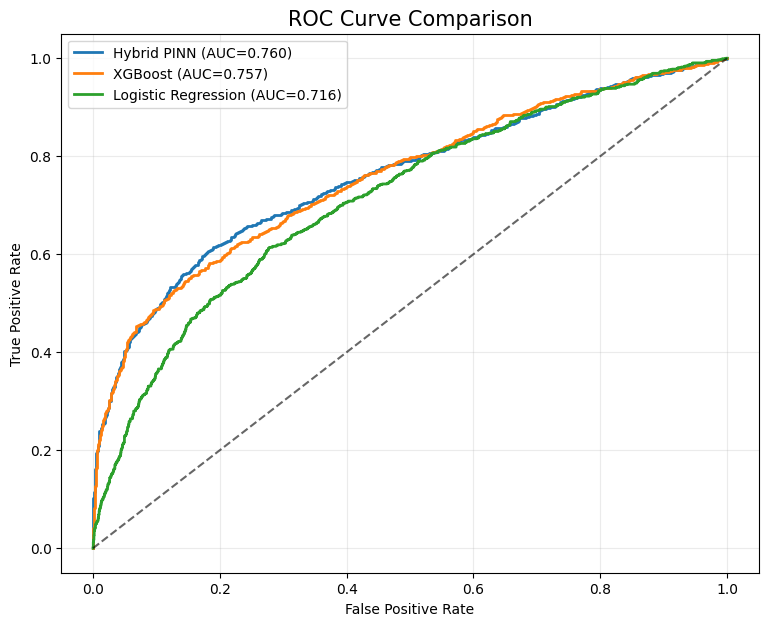

In [45]:
# ============================================================
# ROC CURVES
# ============================================================

plt.figure(figsize=(9,7))

for name, probs in models_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc_val:.3f})")

plt.plot([0,1],[0,1],'k--',alpha=0.6)

plt.title("ROC Curve Comparison", fontsize=15)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

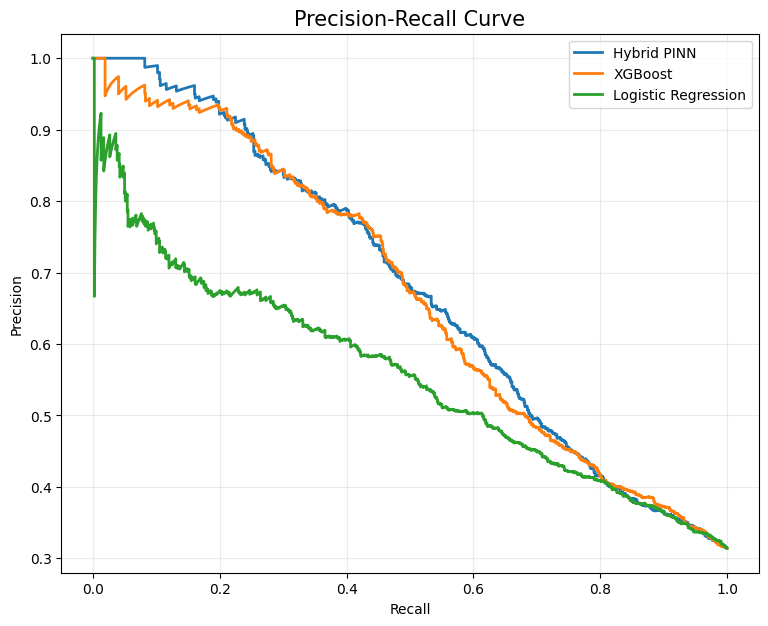

In [47]:
# ============================================================
# PRECISION-RECALL CURVES
# ============================================================

from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
plt.figure(figsize=(9,7))

for name, probs in models_probs.items():
    precision, recall, _ = precision_recall_curve(y_test, probs)
    plt.plot(recall, precision, linewidth=2, label=name)

plt.title("Precision-Recall Curve", fontsize=15)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

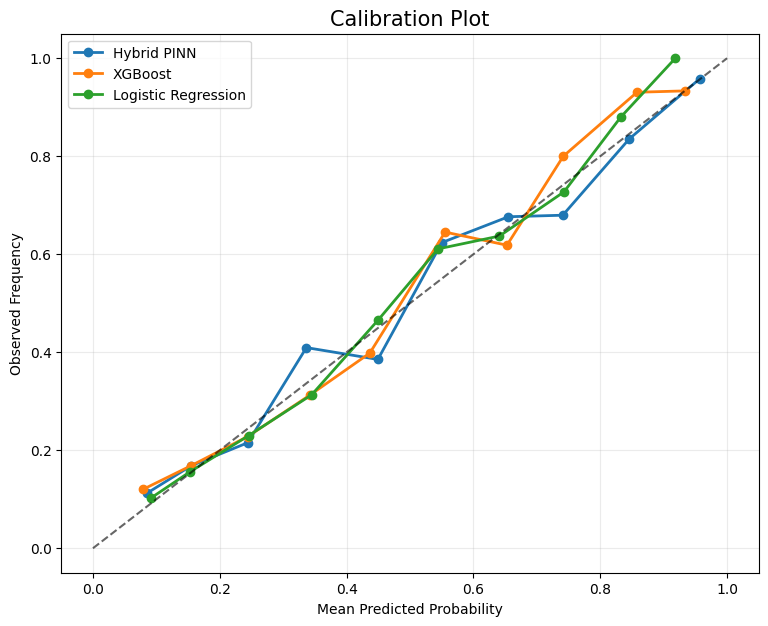

Brier Scores
Hybrid PINN : 0.1634
XGBoost : 0.1645
Logistic Regression : 0.1864


In [54]:
# ============================================================
# CALIBRATION CURVES
# Shows probability reliability
# ============================================================

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

plt.figure(figsize=(9,7))

for name, probs in models_probs.items():

    frac_pos, mean_pred = calibration_curve(
        y_test,
        probs,
        n_bins=10,
        strategy="uniform"
    )

    plt.plot(
        mean_pred,
        frac_pos,
        marker='o',
        linewidth=2,
        label=name
    )

plt.plot([0,1],[0,1],'k--',alpha=0.6)

plt.title("Calibration Plot", fontsize=15)
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Frequency")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

print("Brier Scores")
for name, probs in models_probs.items():
    print(name, ":", round(brier_score_loss(y_test, probs),4))

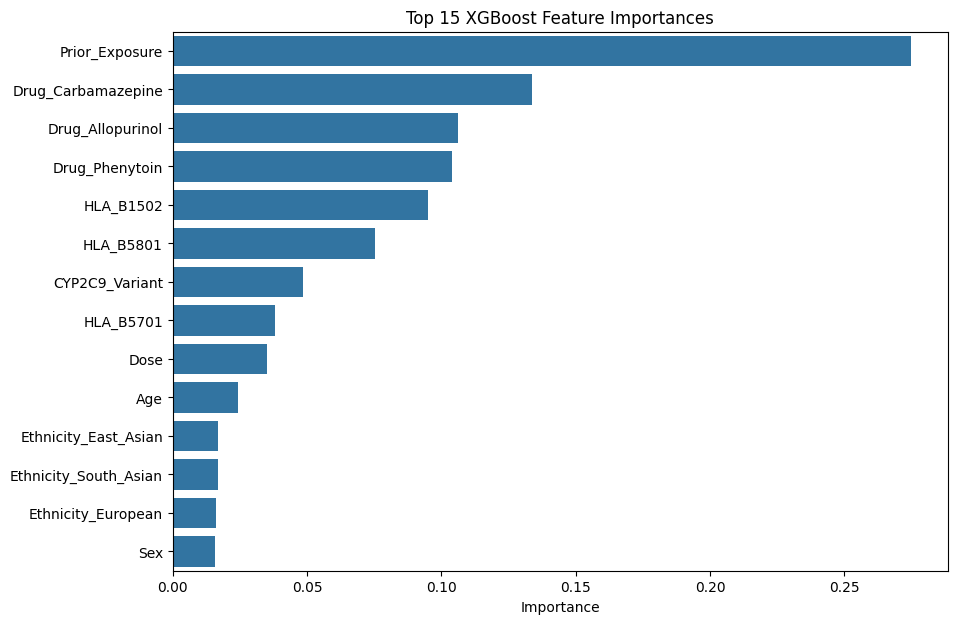

In [55]:
# ============================================================
# XGBOOST FEATURE IMPORTANCE
# ============================================================

imp = pd.Series(
    xgb.feature_importances_,
    index=feature_names
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10,7))
sns.barplot(x=imp.values, y=imp.index)
plt.title("Top 15 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("")
plt.show()

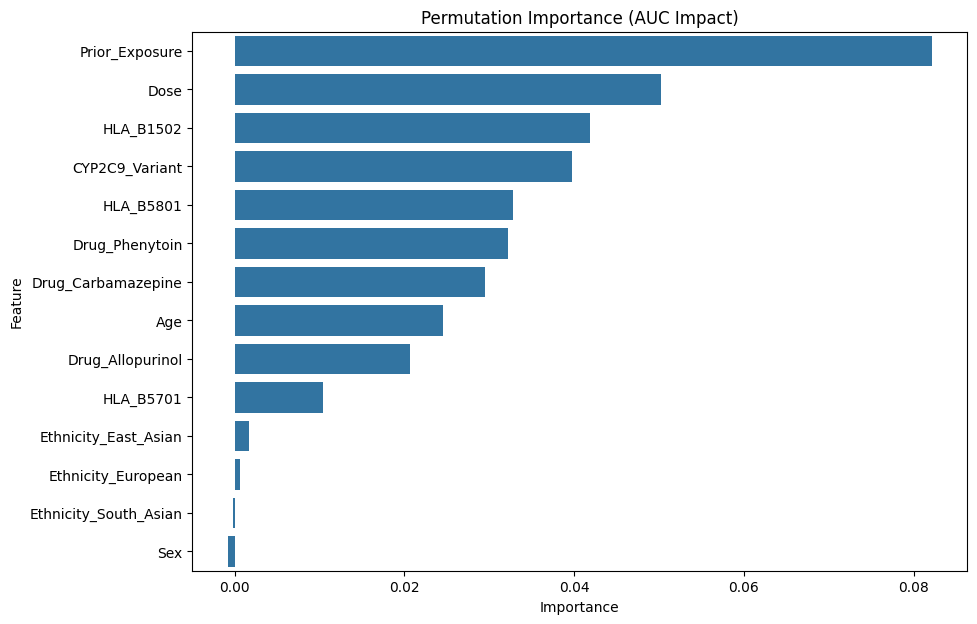

In [57]:
# ============================================================
# PERMUTATION IMPORTANCE (Model Agnostic)
# ============================================================
from sklearn.inspection import permutation_importance
perm = permutation_importance(
    xgb,
    X_test,
    y_test,
    n_repeats=8,
    random_state=42,
    scoring="roc_auc"
)

perm_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": perm.importances_mean
}).sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(10,7))
sns.barplot(data=perm_df, x="Importance", y="Feature")
plt.title("Permutation Importance (AUC Impact)")
plt.show()

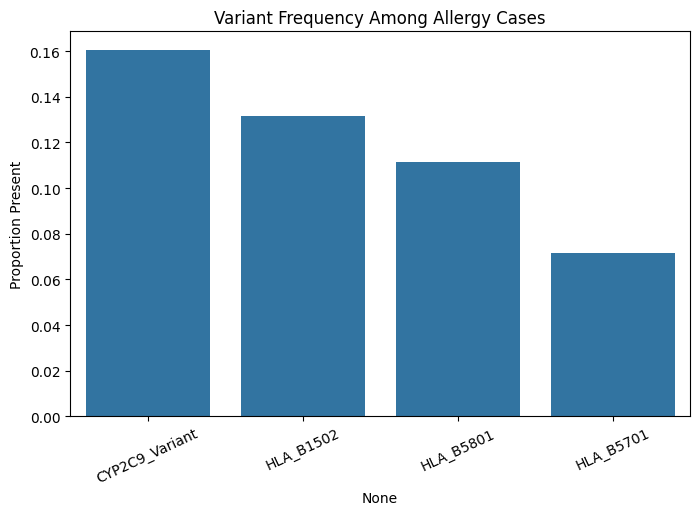

In [58]:
# ============================================================
# RISK GENE FREQUENCY IN POSITIVE CASES
# ============================================================

genes = ["HLA_B5701","HLA_B1502","HLA_B5801","CYP2C9_Variant"]

pos = df[df["Allergy_Risk"]==1]

vals = pos[genes].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=vals.index, y=vals.values)
plt.title("Variant Frequency Among Allergy Cases")
plt.ylabel("Proportion Present")
plt.xticks(rotation=25)
plt.show()

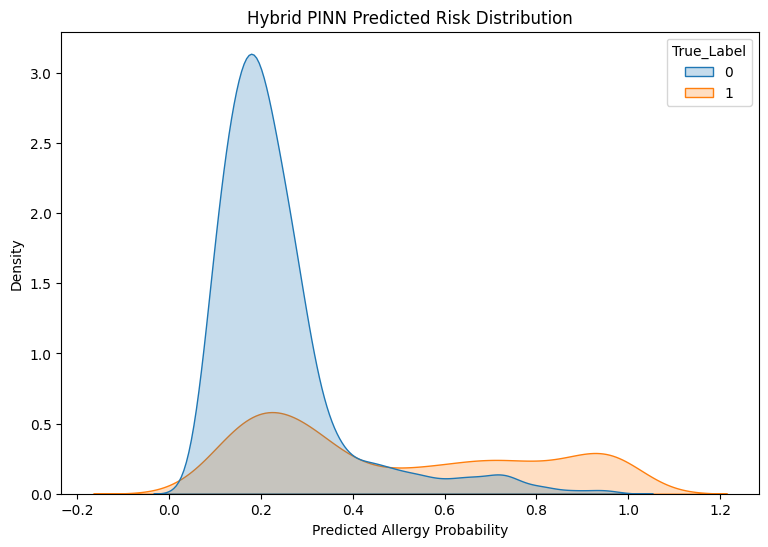

In [59]:
# ============================================================
# PREDICTED RISK DISTRIBUTION BY TRUE CLASS
# ============================================================

plot_df = pd.DataFrame({
    "True_Label": y_test,
    "PINN_Risk": proba_pinn
})

plt.figure(figsize=(9,6))
sns.kdeplot(data=plot_df, x="PINN_Risk", hue="True_Label", fill=True)
plt.title("Hybrid PINN Predicted Risk Distribution")
plt.xlabel("Predicted Allergy Probability")
plt.show()

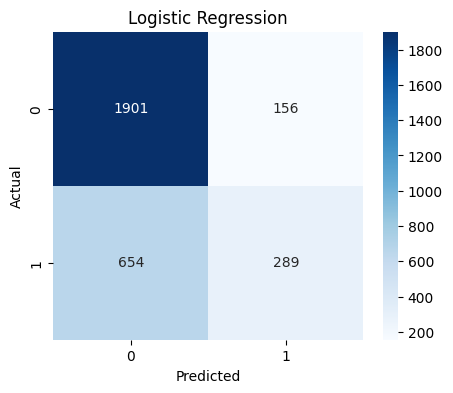

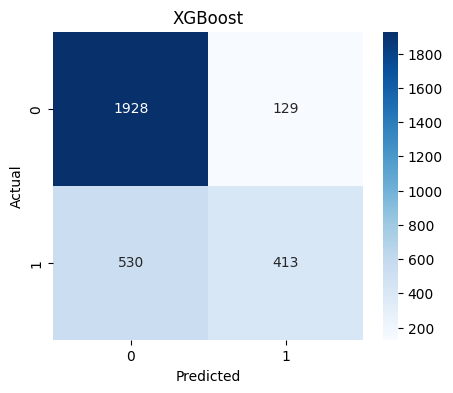

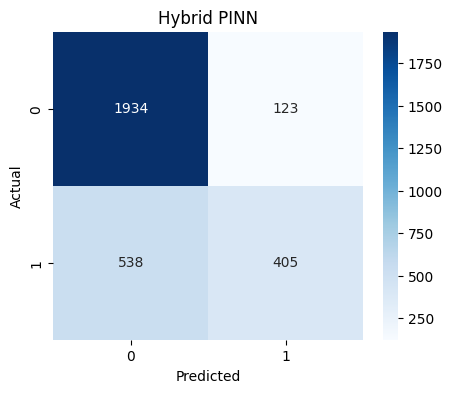

In [60]:
# ============================================================
# CONFUSION MATRIX FOR ALL MODELS
# ============================================================

from sklearn.metrics import confusion_matrix

pred_lr = (proba_lr >= 0.5).astype(int)
pred_xgb = (proba_xgb >= 0.5).astype(int)
pred_pinn = (proba_pinn >= 0.5).astype(int)

pred_map = {
    "Logistic Regression": pred_lr,
    "XGBoost": pred_xgb,
    "Hybrid PINN": pred_pinn
}

for name, preds in pred_map.items():
    cm = confusion_matrix(y_test, preds)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [61]:
# ============================================================
# ABLATION STUDY:
# Plain Neural Network vs PINN
# ============================================================

plain_model = PINNNet(X_train.shape[1]).to(device)

criterion = nn.BCELoss()
optimizer = optim.Adam(plain_model.parameters(), lr=0.001)

epochs = 120

for epoch in range(epochs):
    plain_model.train()
    optimizer.zero_grad()

    y_pred_plain = plain_model(X_train_t)
    loss_plain = criterion(y_pred_plain, y_train_t)

    loss_plain.backward()
    optimizer.step()

plain_model.eval()

with torch.no_grad():
    proba_plain = plain_model(X_test_t).cpu().numpy().flatten()

auc_plain = roc_auc_score(y_test, proba_plain)
auc_pinn  = roc_auc_score(y_test, proba_pinn)

print("Plain MLP AUC :", round(auc_plain,4))
print("Hybrid PINN AUC:", round(auc_pinn,4))

Plain MLP AUC : 0.7548
Hybrid PINN AUC: 0.7599


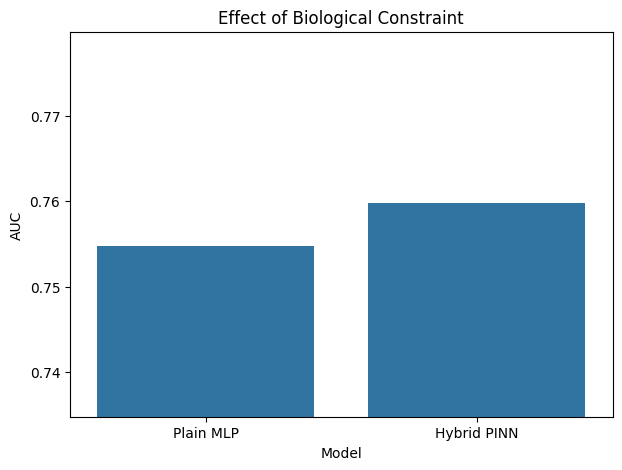

In [62]:
# ============================================================
# ABLATION BAR CHART
# ============================================================

ablation = pd.DataFrame({
    "Model":["Plain MLP","Hybrid PINN"],
    "AUC":[auc_plain, auc_pinn]
})

plt.figure(figsize=(7,5))
sns.barplot(data=ablation, x="Model", y="AUC")
plt.ylim(min(ablation["AUC"])-0.02, max(ablation["AUC"])+0.02)
plt.title("Effect of Biological Constraint")
plt.show()

In [63]:
# ============================================================
# FINAL SUMMARY TABLE
# ============================================================

summary = pd.DataFrame({
    "Model":["Logistic Regression","XGBoost","Plain MLP","Hybrid PINN"],
    "AUC":[
        roc_auc_score(y_test, proba_lr),
        roc_auc_score(y_test, proba_xgb),
        auc_plain,
        roc_auc_score(y_test, proba_pinn)
    ]
})

summary = summary.sort_values("AUC", ascending=False)
print(summary)

                 Model       AUC
3          Hybrid PINN  0.759852
1              XGBoost  0.757235
2            Plain MLP  0.754805
0  Logistic Regression  0.715510


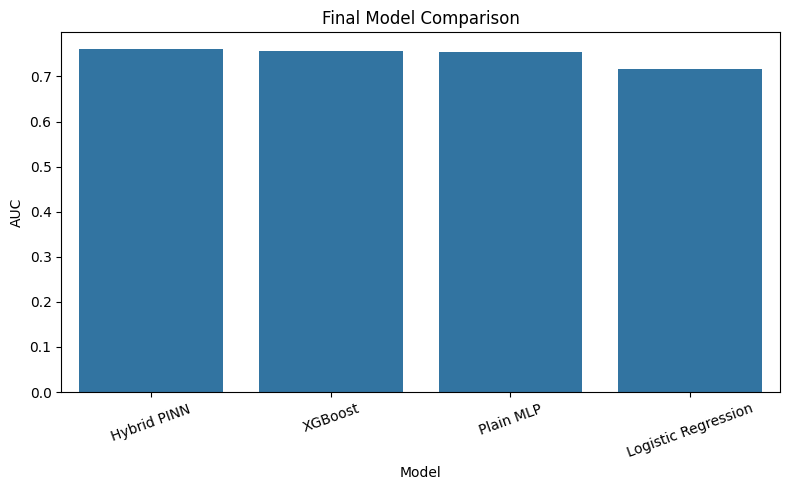

Saved:
- final_model_summary.csv
- final_model_comparison.png


In [64]:
# ============================================================
# SAVE ALL FINAL OUTPUTS
# ============================================================

summary.to_csv("final_model_summary.csv", index=False)

plt.figure(figsize=(8,5))
sns.barplot(data=summary, x="Model", y="AUC")
plt.title("Final Model Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("final_model_comparison.png", dpi=300)
plt.show()

print("Saved:")
print("- final_model_summary.csv")
print("- final_model_comparison.png")